# Dowload dataset

In [20]:
import kagglehub

data_path = kagglehub.dataset_download("akshayksingh/kidney-disease-dataset")
print(f"Dataset path: {data_path}")

Using Colab cache for faster access to the 'kidney-disease-dataset' dataset.
Dataset path: /kaggle/input/kidney-disease-dataset


# Import Libraries

In [21]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

# Cấu hình hiển thị và cảnh báo
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
%matplotlib inline

# Read Dataset And Information

In [22]:
# Đường dẫn file dữ liệu cụ thể
csv_file = os.path.join(data_path, "kidney_disease.csv")
df = pd.read_csv(csv_file)

# Data Preprocessing

In [23]:
# Tiền xử lý dữ liệu thô
df.drop('id', axis=1, inplace=True, errors='ignore')

# Ép kiểu dữ liệu số
for col in ['pcv', 'wc', 'rc']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Chuẩn hóa nhãn văn bản
def clean_labels(data):
    obj_cols = data.select_dtypes(include='object').columns
    for col in obj_cols:
        data[col] = data[col].str.replace('\t', '').str.strip()
        data[col] = data[col].replace({
            'ckd\t': 'ckd', 'notckd': 'not ckd',
            'yes\t': 'yes', '\tno': 'no', '\tyes': 'yes'
        })
    return data

df = clean_labels(df)
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

None

In [24]:
from sklearn.model_selection import train_test_split

# Chia tập Train/Test theo tỷ lệ 8:2
X = df.drop('classification', axis=1)
y = df['classification']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# Xử lý giá trị thiếu bằng Median (số) và Mode (phân loại)
num_cols = X_train.select_dtypes(exclude='object').columns
cat_cols = X_train.select_dtypes(include='object').columns

for col in num_cols:
    fill_val = X_train[col].median()
    X_train[col].fillna(fill_val, inplace=True)
    X_test[col].fillna(fill_val, inplace=True)

for col in cat_cols:
    fill_val = X_train[col].mode()[0] if not X_train[col].mode().empty else 'unknown'
    X_train[col].fillna(fill_val, inplace=True)
    X_test[col].fillna(fill_val, inplace=True)

In [26]:
from sklearn.preprocessing import LabelEncoder

# Mã hóa đặc trưng phân loại
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = X_test[col].map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

In [27]:
from sklearn.preprocessing import LabelEncoder

remaining_cat_cols = X_train.select_dtypes(include=['object']).columns
print(f"Encoding remaining columns: {list(remaining_cat_cols)}")

for col in remaining_cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

print("All columns converted to numerical format.")
display(X_train.head())


Encoding remaining columns: []
All columns converted to numerical format.


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane
380,59.0,60.0,1.020,0.0,0.0,1,1,0,0,113.0,...,15.3,54.0,6500.0,4.9,0,0,0,0,0,0
56,76.0,70.0,1.015,3.0,4.0,1,0,1,0,120.0,...,10.2,30.0,11300.0,3.4,1,1,1,1,1,0
126,70.0,90.0,1.015,0.0,0.0,1,1,0,0,144.0,...,12.0,37.0,8200.0,4.5,1,1,0,1,1,0
371,28.0,60.0,1.025,0.0,0.0,1,1,0,0,79.0,...,17.6,51.0,6500.0,5.0,0,0,0,0,0,0
333,23.0,80.0,1.020,0.0,0.0,1,1,0,0,99.0,...,17.7,46.0,4300.0,5.5,0,0,0,0,0,0


### 7. Thiết lập hệ thống Logging chuẩn (Unified Logger)

In [28]:
import json
import datetime
import os

def save_experiment_report(model_name, category, params, metrics):
    """Lưu báo cáo thí nghiệm vào thư mục models/."""
    path = f"models/{model_name}"
    os.makedirs(path, exist_ok=True)

    report = {
        "meta": {
            "timestamp": datetime.datetime.now().isoformat(),
            "model_name": model_name,
            "category": category,
            "random_state": 42
        },
        "params": params,
        "metrics": metrics
    }

    file_path = os.path.join(path, "experiment_log.json")
    with open(file_path, 'w') as f:
        json.dump(report, f, indent=4)

    print(f"[Log] Đã lưu báo cáo tại {file_path}")
    return report

# Model

## 1. Logistic Regression (Non-Iterative/Solver-based)

[Log] Đã lưu báo cáo tại models/LogisticRegression/experiment_log.json
[Checkpoint] Đã lưu model tại models/LogisticRegression/model.joblib


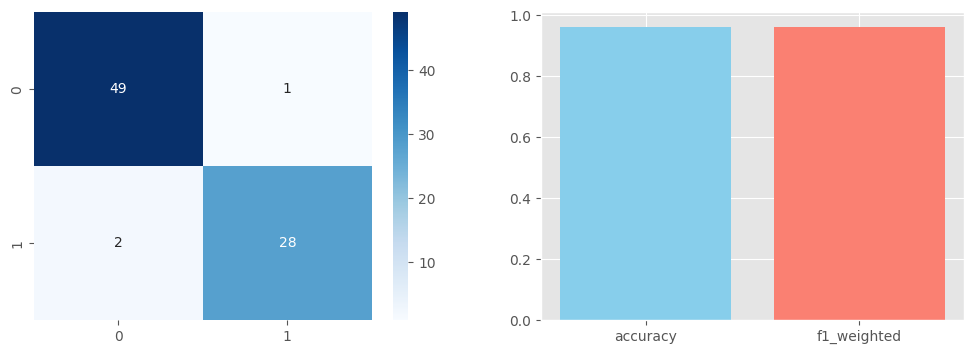

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

name = "LogisticRegression"
params = {"solver": "liblinear", "C": 1.0}
model = LogisticRegression(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

# Lưu Log và Checkpoint
save_experiment_report(name, "non-iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Blues')
ax[1].bar(metrics.keys(), metrics.values(), color=['skyblue', 'salmon'])
plt.show()

## 2. Decision Tree (Structural)

[Log] Đã lưu báo cáo tại models/DecisionTree/experiment_log.json
[Checkpoint] Đã lưu model tại models/DecisionTree/model.joblib


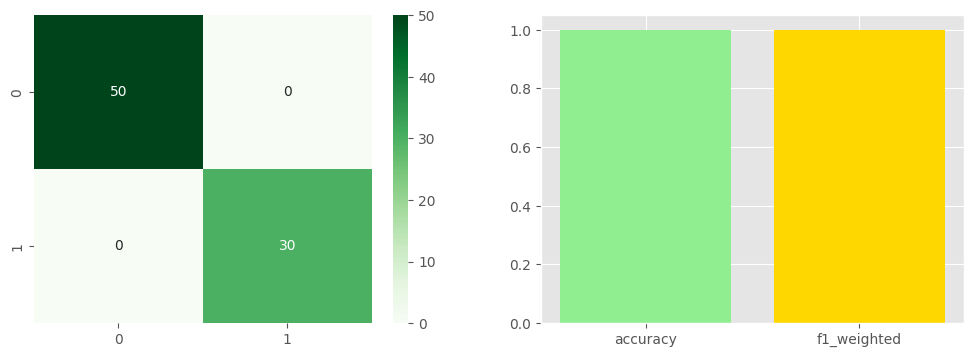

In [30]:
from sklearn.tree import DecisionTreeClassifier

name = "DecisionTree"
params = {"criterion": "entropy", "max_depth": 5, "random_state": 42}
model = DecisionTreeClassifier(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

save_experiment_report(name, "non-iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Greens')
ax[1].bar(metrics.keys(), metrics.values(), color=['lightgreen', 'gold'])
plt.show()

## 3. Support Vector Machine - SVM (Non-Iterative)

[Log] Đã lưu báo cáo tại models/SVM/experiment_log.json
[Checkpoint] Đã lưu model tại models/SVM/model.joblib


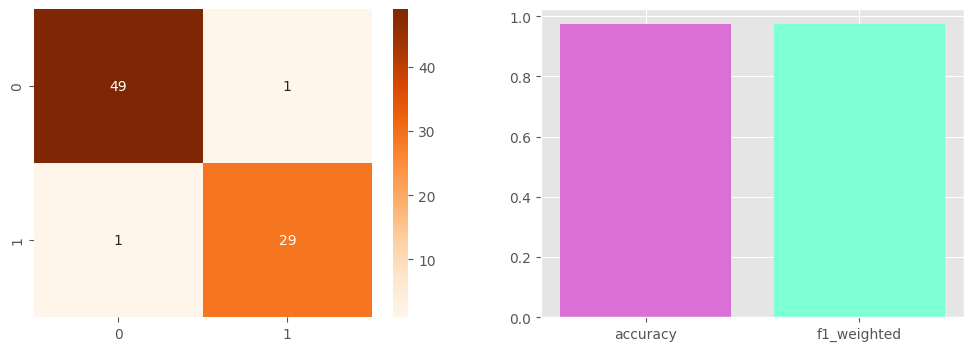

In [31]:
from sklearn.svm import SVC

name = "SVM"
params = {"kernel": "linear", "C": 1.0}
model = SVC(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

save_experiment_report(name, "non-iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='Oranges')
ax[1].bar(metrics.keys(), metrics.values(), color=['orchid', 'aquamarine'])
plt.show()

## 4. K-Nearest Neighbors - KNN (Lazy Learner)

[Log] Đã lưu báo cáo tại models/KNN/experiment_log.json
[Checkpoint] Đã lưu model tại models/KNN/model.joblib


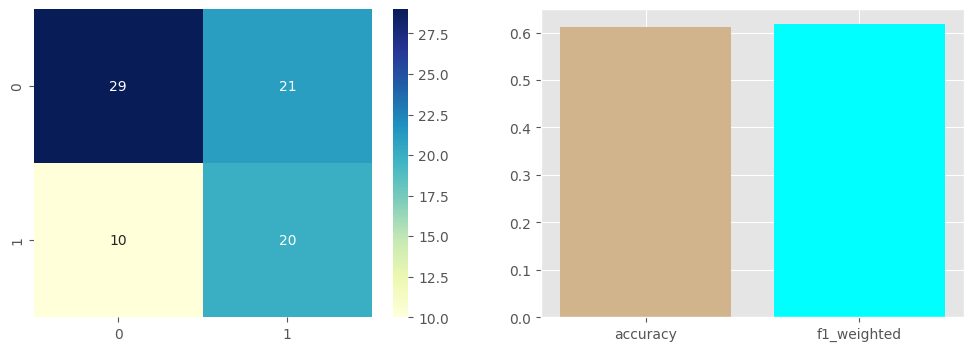

In [32]:
from sklearn.neighbors import KNeighborsClassifier

name = "KNN"
params = {"n_neighbors": 5}
model = KNeighborsClassifier(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

save_experiment_report(name, "non-iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='YlGnBu')
ax[1].bar(metrics.keys(), metrics.values(), color=['tan', 'cyan'])
plt.show()

## 5. XGBoost (Iterative/Boosting with Early Stopping)

[Log] Đã lưu báo cáo tại models/XGBoost/experiment_log.json
[Checkpoint] Đã lưu model tại models/XGBoost/model.joblib


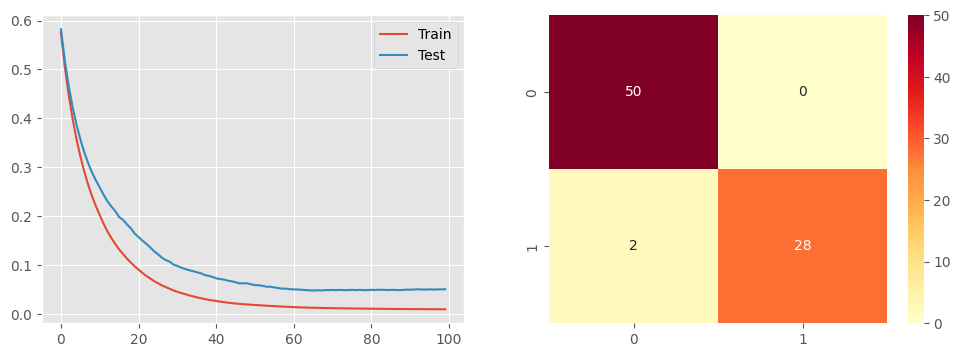

In [33]:
from xgboost import XGBClassifier

name = "XGBoost"
params = {"n_estimators": 100, "learning_rate": 0.1, "max_depth": 3, "random_state": 42, "eval_metric": "logloss"}
model = XGBClassifier(**params)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

y_pred = model.predict(X_test)
results = model.evals_result()
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

save_experiment_report(name, "iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(results['validation_0']['logloss'], label='Train')
ax[0].plot(results['validation_1']['logloss'], label='Test')
ax[0].legend()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[1], cmap='YlOrRd')
plt.show()

## 6. Random Forest (Ensemble/Structural)

[Log] Đã lưu báo cáo tại models/RandomForest/experiment_log.json
[Checkpoint] Đã lưu model tại models/RandomForest/model.joblib


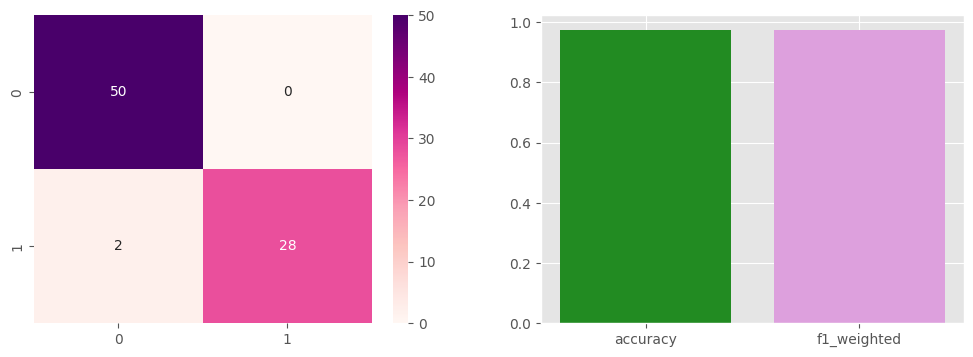

In [34]:
from sklearn.ensemble import RandomForestClassifier

name = "RandomForest"
params = {"n_estimators": 100, "random_state": 42}
model = RandomForestClassifier(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

save_experiment_report(name, "non-iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], cmap='RdPu')
ax[1].bar(metrics.keys(), metrics.values(), color=['forestgreen', 'plum'])
plt.show()

## 7. Gradient Boosting Decision Tree - GBDT (Iterative)

[Log] Đã lưu báo cáo tại models/GBDT/experiment_log.json
[Checkpoint] Đã lưu model tại models/GBDT/model.joblib


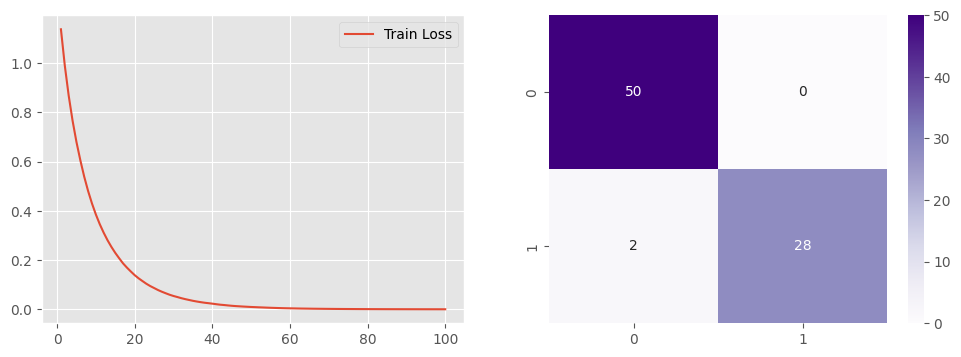

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

name = "GBDT"
params = {"n_estimators": 100, "learning_rate": 0.1, "random_state": 42}
model = GradientBoostingClassifier(**params)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
metrics = {"accuracy": accuracy_score(y_test, y_pred), "f1_weighted": f1_score(y_test, y_pred, average='weighted')}

save_experiment_report(name, "iterative", params, metrics)
joblib.dump(model, f"models/{name}/model.joblib")
print(f"[Checkpoint] Đã lưu model tại models/{name}/model.joblib")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(np.arange(params['n_estimators']) + 1, model.train_score_, label='Train Loss')
ax[0].legend()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', ax=ax[1], cmap='Purples')
plt.show()

# 8. Model Performance Comparison
Compare all trained models based on their logged metrics.

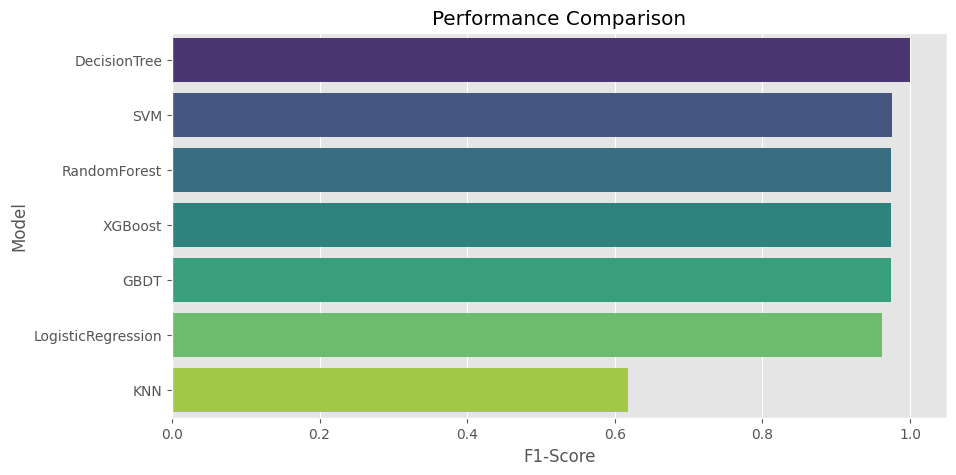

,Model,Accuracy,F1-Score
0,DecisionTree,1.0000,1.000000
1,SVM,0.9750,0.975000
3,RandomForest,0.9750,0.974814
6,XGBoost,0.9750,0.974814
5,GBDT,0.9750,0.974814
4,LogisticRegression,0.9625,0.962368
2,KNN,0.6125,0.618571


In [36]:
import pandas as pd
import glob
import json
import seaborn as sns
import matplotlib.pyplot as plt

# Tổng hợp kết quả
logs = []
for f_path in glob.glob('models/*/experiment_log.json'):
    with open(f_path, 'r') as f:
        logs.append(json.load(f))

if not logs:
    print("Không tìm thấy log. Hãy chạy các cell training trước.")
else:
    data = [{
        'Model': l['meta']['model_name'],
        'Accuracy': l['metrics']['accuracy'],
        'F1-Score': l['metrics']['f1_weighted']
    } for l in logs]

    res_df = pd.DataFrame(data).sort_values('F1-Score', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='F1-Score', y='Model', data=res_df, palette='viridis')
    plt.title('Performance Comparison')
    plt.show()
    display(res_df)

In [37]:
import json
import os
import glob
import pandas as pd

# Cấu hình chung của project
project_metadata = {
    "project_name": "Kidney Disease Classification",
    "dataset_version": "akshayksingh/kidney-disease-dataset",
    "random_seed": 42,
    "split_ratio": {"train": 0.8, "test": 0.2},
    "preprocessing": "Median/Mode Imputation + Label Encoding",
    "models_dir": "models/"
}

# Thu thập thông tin từ các log đã lưu
handoff_data = {"project_info": project_metadata, "models": []}

log_files = glob.glob('models/*/experiment_log.json')
for f_path in log_files:
    with open(f_path, 'r') as f:
        log = json.load(f)
        model_name = log['meta']['model_name']

        # Cập nhật đường dẫn artifact chính xác tới checkpoint .joblib
        log['artifacts'] = {
            "checkpoint": f"models/{model_name}/model.joblib",
            "log": f_path
        }
        handoff_data["models"].append(log)

# Lưu file bàn giao cuối cùng
with open('final_handoff_report.json', 'w') as f:
    json.dump(handoff_data, f, indent=4)

print("✅ Đã cập nhật báo cáo bàn giao với đường dẫn Checkpoint chính xác.")

# Hiển thị tóm tắt trạng thái bàn giao
summary = pd.DataFrame([{
    "Model": m['meta']['model_name'],
    "Category": m['meta']['category'],
    "Accuracy": m['metrics']['accuracy'],
    "Checkpoint Status": "Saved (.joblib)"
} for m in handoff_data['models']])
display(summary)

✅ Đã cập nhật báo cáo bàn giao với đường dẫn Checkpoint chính xác.


,Model,Category,Accuracy,Checkpoint Status
0,DecisionTree,non-iterative,1.0000,Saved (.joblib)
1,SVM,non-iterative,0.9750,Saved (.joblib)
2,KNN,non-iterative,0.6125,Saved (.joblib)
3,RandomForest,non-iterative,0.9750,Saved (.joblib)
4,LogisticRegression,non-iterative,0.9625,Saved (.joblib)
5,GBDT,iterative,0.9750,Saved (.joblib)
6,XGBoost,iterative,0.9750,Saved (.joblib)
